In [13]:
import numpy as np
import pandas as pd

df=pd.read_csv('data/mushrooms.csv')

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [14]:
print(df.shape)
print(df.isnull().sum())
print(df.info)
print(df.columns)

(8124, 23)
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64
<bound method DataFrame.info of      class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0        p         x           s         n       t    p               f   
1        e         x           s         y       t    a               f   
2        e         b         

In [15]:
print(df['class'].value_counts())

class
e    4208
p    3916
Name: count, dtype: int64


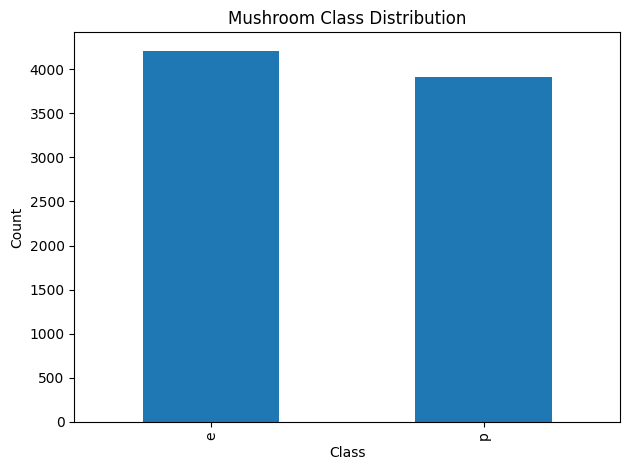

In [16]:
import matplotlib.pyplot as plt

df['class'].value_counts().plot(
    kind="bar"
)

plt.title("Mushroom Class Distribution")

plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig("images/class_distribution.png",dpi=300,bbox_inches="tight")

plt.tight_layout()
plt.show()

In [17]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

class: 2 unique values
cap-shape: 6 unique values
cap-surface: 4 unique values
cap-color: 10 unique values
bruises: 2 unique values
odor: 9 unique values
gill-attachment: 2 unique values
gill-spacing: 2 unique values
gill-size: 2 unique values
gill-color: 12 unique values
stalk-shape: 2 unique values
stalk-root: 5 unique values
stalk-surface-above-ring: 4 unique values
stalk-surface-below-ring: 4 unique values
stalk-color-above-ring: 9 unique values
stalk-color-below-ring: 9 unique values
veil-type: 1 unique values
veil-color: 4 unique values
ring-number: 3 unique values
ring-type: 5 unique values
spore-print-color: 9 unique values
population: 6 unique values
habitat: 7 unique values


In [18]:
df=df.drop("veil-type",axis=1)

# print(df.columns)
print(df.shape)

(8124, 22)


In [19]:
X=df.drop("class",axis=1)
y=df["class"]

In [20]:
print(X.shape)
print(y.shape)

(8124, 21)
(8124,)


In [21]:
X=pd.get_dummies(X,dtype=int)

print(X.shape)
print(y.shape)

(8124, 116)
(8124,)


In [22]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,test_size=0.2
)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_Scaled=scaler.transform(X_test)

In [24]:
import joblib

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

['models/scaler.pkl']

In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder=LabelEncoder()

y_train=label_encoder.fit_transform(y_train)
y_test=label_encoder.transform(y_test)

joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
)

['models/label_encoder.pkl']

LOGISTIC REGRESSION

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

lr_model=LogisticRegression()

lr_model.fit(X_train_scaled,y_train)
y_pred_lr=lr_model.predict(X_test_Scaled)

print("Logistic Regression")
print("Accuracy: ",accuracy_score(y_test,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

Logistic Regression
Accuracy:  1.0
[[843   0]
 [  0 782]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [27]:
print("Training Score: ",lr_model.score(X_train_scaled,y_train))
print("Testing Score: ",lr_model.score(X_test_Scaled,y_test))

Training Score:  1.0
Testing Score:  1.0


DECISION TREE

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)


In [29]:
print("Decision Tree")
print("Accuracy: ",accuracy_score(y_test,y_pred_dt))
print(confusion_matrix(y_test,y_pred_dt))
print(classification_report(y_test,y_pred_dt))

Decision Tree
Accuracy:  1.0
[[843   0]
 [  0 782]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [32]:
print("Training Score: ",dt.score(X_train_scaled,y_train))
print("Testing Score: ",dt.score(X_test_Scaled,y_test))

Training Score:  1.0
Testing Score:  1.0


c:\Users\kamal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\kamal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


RANDOM-FOREST


In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 1.0
[[843   0]
 [  0 782]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



SVM

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_Scaled
)

print("Support Vector Machine")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print(confusion_matrix(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

Support Vector Machine
Accuracy: 1.0
[[843   0]
 [  0 782]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



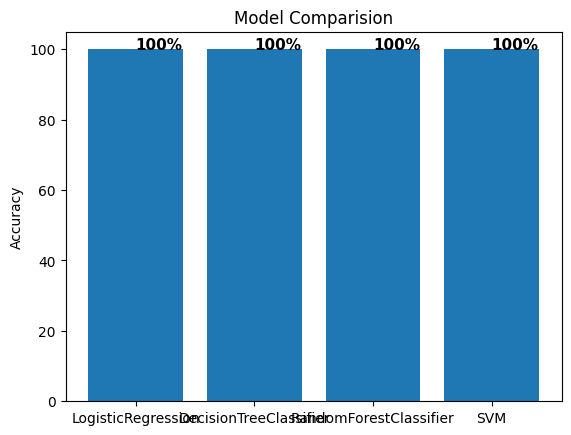

In [36]:
models=["LogisticRegression",
        "DecisionTreeClassifier",
        "RandomForestClassifier",
        "SVM"        
]

accuracy=[
    100,100,100,100
]

plt.Figure(figsize=(8,5))

bars=plt.bar(models,accuracy)

plt.title("Model Comparision")
plt.ylabel("Accuracy")

for bar in bars:
    height=bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:.0f}%",
        fontsize=11,
        fontweight="bold"
              )
plt.savefig(
    "images/model_comparision.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()

In [37]:
import joblib

joblib.dump(
    svm_model,
    "models/mushroom_model.pkl"
)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

joblib.dump(
    label_encoder,
    "models/label_encoder.pkl"
)

print("Everything Saved Successfully!")

Everything Saved Successfully!


In [38]:
import joblib

joblib.dump(
    X.columns.tolist(),
    "models/model_columns.pkl"
)

print("Columns Saved Successfully!")

Columns Saved Successfully!
